In [15]:
# imports
import concurrent.futures

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import eigs
from tqdm import tqdm

from chebyshev_hofbauer_resonances.general_tent_map.approx_transfer_op import (
    approx_super_adjacency,
)

In [2]:
# function definition
def t_map(alpha):
    function_domains = [(0, 0.5), (0.5, 1)]
    functions = [lambda x: alpha * x, lambda x: alpha * (1 - x)]
    inverses = [lambda y: y / alpha, lambda y: 1 - (y / alpha)]
    derivatives = [lambda _: alpha, lambda _: -alpha]

    return function_domains, functions, inverses, derivatives

In [14]:
def get_lam2(alpha):
    function_domains, functions, inverses, derivatives = t_map(alpha)

    super_adjacency = approx_super_adjacency(
        function_domains,
        functions,
        inverses,
        derivatives,
        N=2,
        K=2,
        depth=50,
    )

    evals_super_adj = np.linalg.eigvals(super_adjacency)
    evals_super_adj = evals_super_adj[np.argsort(-np.abs(evals_super_adj))]

    lam2 = evals_super_adj[1]
    return lam2

In [ ]:
lam2s = []
alphas = np.linspace(1.6, 1.7, 10_001)

NUM_CPUS = 6
chunk_size = max(1, len(alphas) // NUM_CPUS)

print(f"Starting processing on {NUM_CPUS} CPUs with batch size {chunk_size}...")

with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_CPUS) as executor:
        results_generator = executor.map(get_lam2, alphas, chunksize=chunk_size)

        list(tqdm(results_generator, total=len(alphas), desc="Processing Alphas"))

Starting processing on 6 CPUs with batch size 1666...


Processing Alphas:   0%|          | 0/10001 [00:00<?, ?it/s]


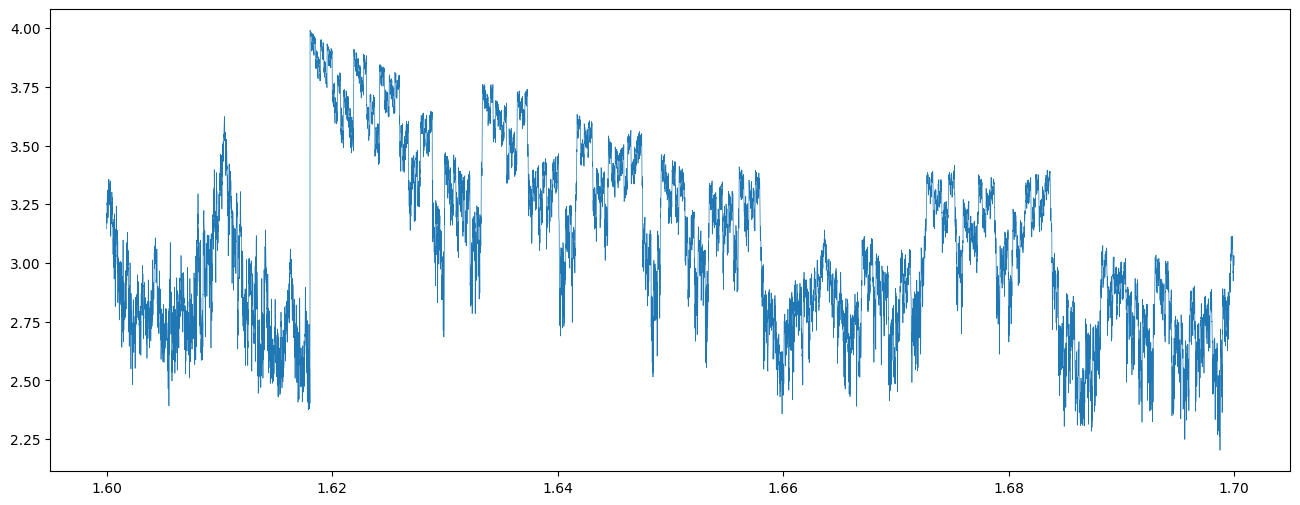

In [13]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(alphas, -1/np.log(np.abs(np.array(lam2s))), linewidth=0.5)

plt.show()

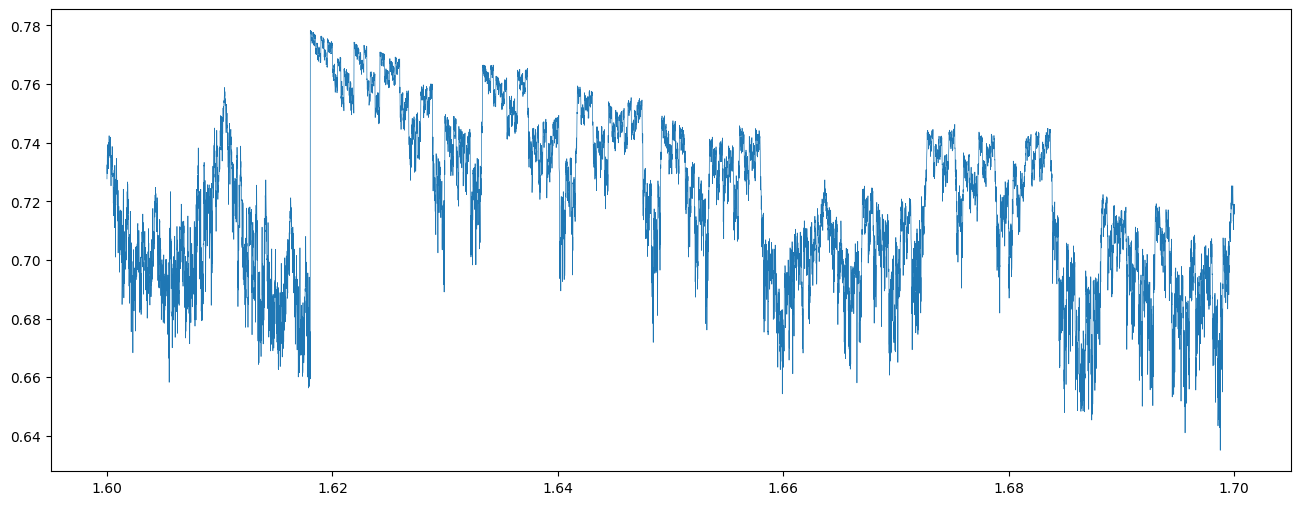

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(alphas, np.abs(np.array(lam2s)), linewidth=0.5)

plt.show()